#"""
#Multilayer Perceptron (MLP) from scratch using NumPy.

#Features:
- Dense layers
- ReLU and Softmax activations
- CrossEntropy loss
- Simple training loop

# """

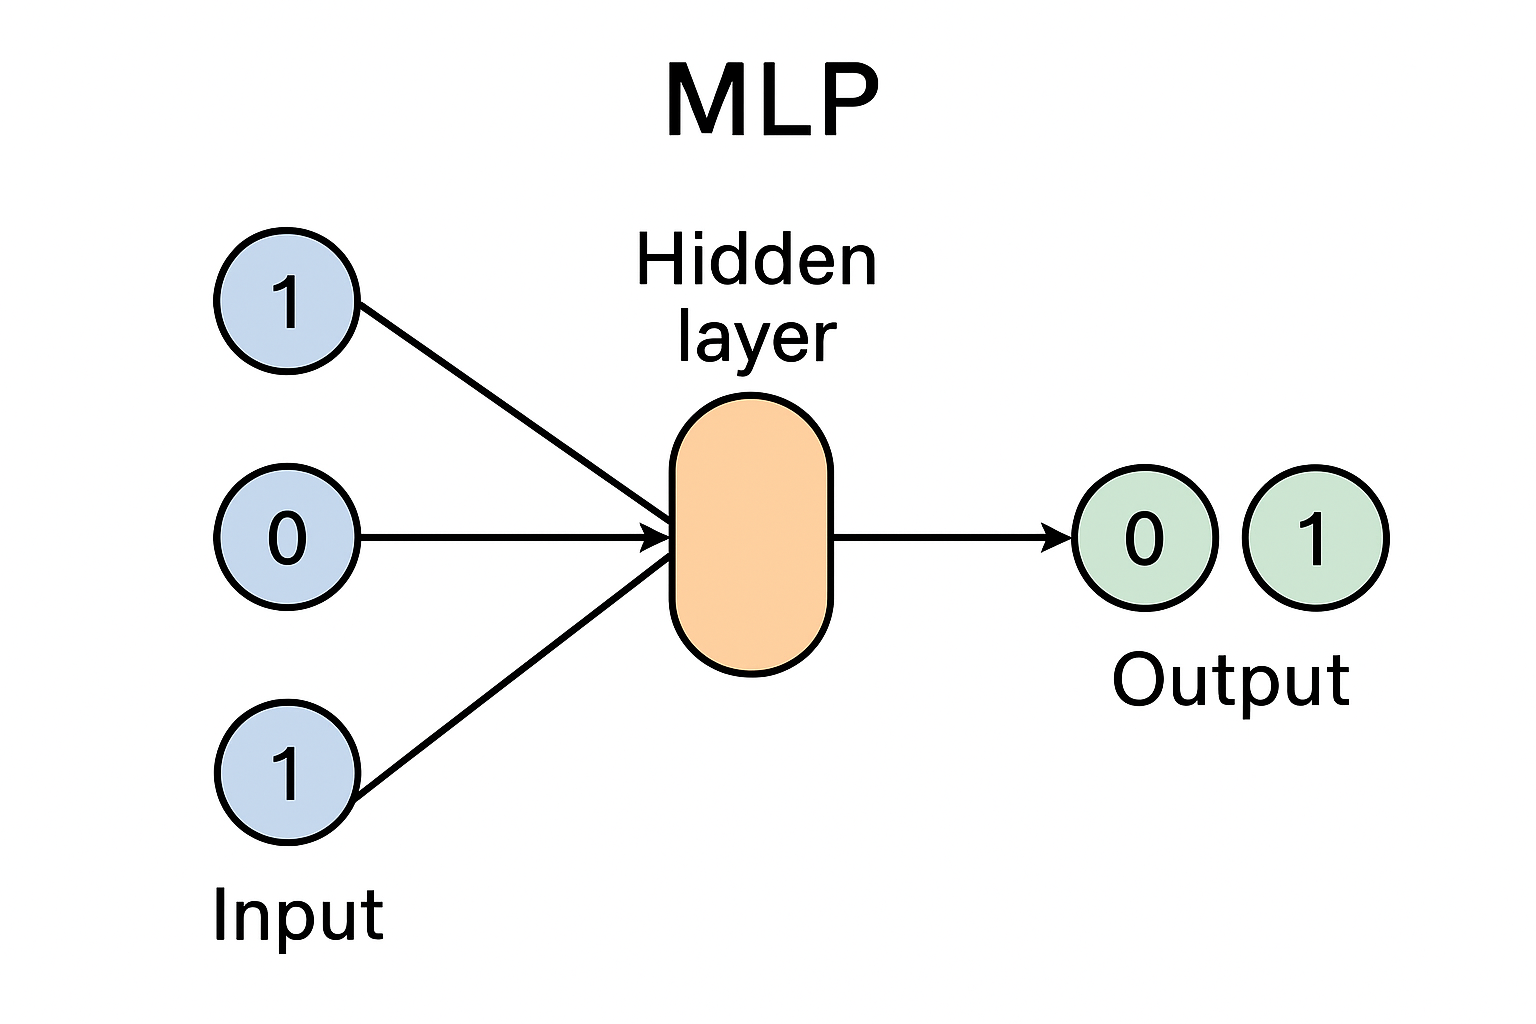

In [1]:
import numpy as np
np.random.seed(42)

In [2]:
def one_hot(y,num_classes):
  y  = y.astype(int)
  oh = np.zeros((len(y),num_classes))
  oh[np.arange(len(y)),y] = 1
  return oh

In [12]:
import numpy as np

class Dense:
    def __init__(self, in_features, out_features, activation=None):
        self.W = 0.01 * np.random.randn(in_features, out_features)
        self.b = np.zeros((1, out_features))
        self.activation = activation

    def forward(self, X):
        self.X = X
        self.z = X @ self.W + self.b
        return self.activation(self.z) if self.activation else self.z

    def backward(self, grad_out, lr):
        if self.activation and self.activation != softmax:
            grad_out = grad_out * self.activation(self.z, grad=True)
        dW = self.X.T @ grad_out
        db = grad_out.sum(axis=0, keepdims=True)
        grad_in = grad_out @ self.W.T
        self.W -= lr * dW
        self.b -= lr * db
        return grad_in

In [13]:
def relu(x,grad = False):
  if grad:
    return (x > 0).astype(float)
  return np.maximum(0,x)

In [14]:
def softmax(x, grad=False):
    if grad:
        raise NotImplementedError("Softmax grad is combined with CrossEntropy")
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


In [15]:
def cross_entropy(y_true, y_pred):
    m = y_true.shape[0]
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    loss = -np.sum(y_true * np.log(y_pred)) / m
    grad = (y_pred - y_true) / m
    return loss, grad

In [16]:
class MLP:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, X):
        out = X
        for layer in self.layers:
            out = layer.forward(out)
        return out

    def backward(self, grad, lr):
        for layer in reversed(self.layers):
            grad = layer.backward(grad, lr)

    def predict(self, X):
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

    def fit(self, X, y, lr=0.1, epochs=100):
        y_onehot = one_hot(y, self.layers[-1].W.shape[1])
        for epoch in range(1, epochs+1):
            out = self.forward(X)
            loss, grad = cross_entropy(y_onehot, out)
            self.backward(grad, lr)
            if epoch % (epochs // 10) == 0 or epoch == 1:
                preds = self.predict(X)
                acc = (preds == y).mean()
                print(f"Epoch {epoch}/{epochs} | loss={loss:.4f} acc={acc:.3f}")

In [18]:
def demo_xor():
    X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
    y = np.array([0,1,1,0])

    model = MLP([
        Dense(2, 4, activation=relu),
        Dense(4, 2, activation=softmax),
    ])
    model.fit(X, y, lr=0.1, epochs=1000)
    print("Predictions:", model.predict(X))
    print("Labels:     ", y)


In [19]:
 demo_xor()

Epoch 1/1000 | loss=0.6931 acc=0.750
Epoch 100/1000 | loss=0.6929 acc=1.000
Epoch 200/1000 | loss=0.6902 acc=1.000
Epoch 300/1000 | loss=0.6610 acc=1.000
Epoch 400/1000 | loss=0.4774 acc=1.000
Epoch 500/1000 | loss=0.1981 acc=1.000
Epoch 600/1000 | loss=0.0920 acc=1.000
Epoch 700/1000 | loss=0.0540 acc=1.000
Epoch 800/1000 | loss=0.0370 acc=1.000
Epoch 900/1000 | loss=0.0277 acc=1.000
Epoch 1000/1000 | loss=0.0219 acc=1.000
Predictions: [0 1 1 0]
Labels:      [0 1 1 0]
